# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Mohamed Elkassem Ahmed  
**Student ID:** 1210112

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [2]:

# ── Task 1: Data Pipeline ──────────────────────────────────────────────
from sklearn.impute import SimpleImputer

# 1. Load the dataset
df = pd.read_csv('kidney_disease.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

# 2. Encode target: 'ckd' -> 1, 'notckd' -> 0
df['classification'] = df['classification'].str.strip().map({'ckd': 1, 'notckd': 0})

# 3. Drop the 'id' column (not a clinical feature)
df.drop('id', axis=1, inplace=True)

# 4. Drop all categorical (object/string) columns – keep only numerical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Dropping categorical columns: {categorical_cols}")
df.drop(categorical_cols, axis=1, inplace=True)

# 5. Force remaining columns to numeric (handles hidden whitespace / tabs)
for col in df.columns:
    if col != 'classification':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nNumeric features kept: {[c for c in df.columns if c != 'classification']}")
print(f"Shape after cleanup: {df.shape}")
print(f"Missing values per column:\n{df.isnull().sum()}\n")

# 6. Separate features (X) and target (y)
y = df['classification'].values
X = df.drop('classification', axis=1)

# 7. 80/20 train / validation split (stratified to preserve class balance)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Impute NaN with training-set median (prevents data leakage)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)

# 9. Standardise features (fit on training set only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f"Training set  : {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples, {X_val.shape[1]} features")
print(f"Train target dist → CKD: {int(y_train.sum())}, Not CKD: {int(len(y_train) - y_train.sum())}")
print(f"Val   target dist → CKD: {int(y_val.sum())},   Not CKD: {int(len(y_val) - y_val.sum())}")


Dataset shape: (400, 26)
Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Dropping categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Numeric features kept: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']
Shape after cleanup: (400, 12)
Missing values per column:
age                9
bp                12
sg                47
al                46
su                49
bgr               44
bu                19
sc                17
sod               87
pot               88
hemo              52
classification     0
dtype: int64

Training set  : 320 samples, 11 features
Validation set: 80 samples, 11 features
Train target dist → CKD: 200, Not CKD: 120
Val   target dist → CKD: 50,   Not CKD: 30


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               3072      
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 128)               16512     
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 126593 (494.50 KB)
Trainable params: 126

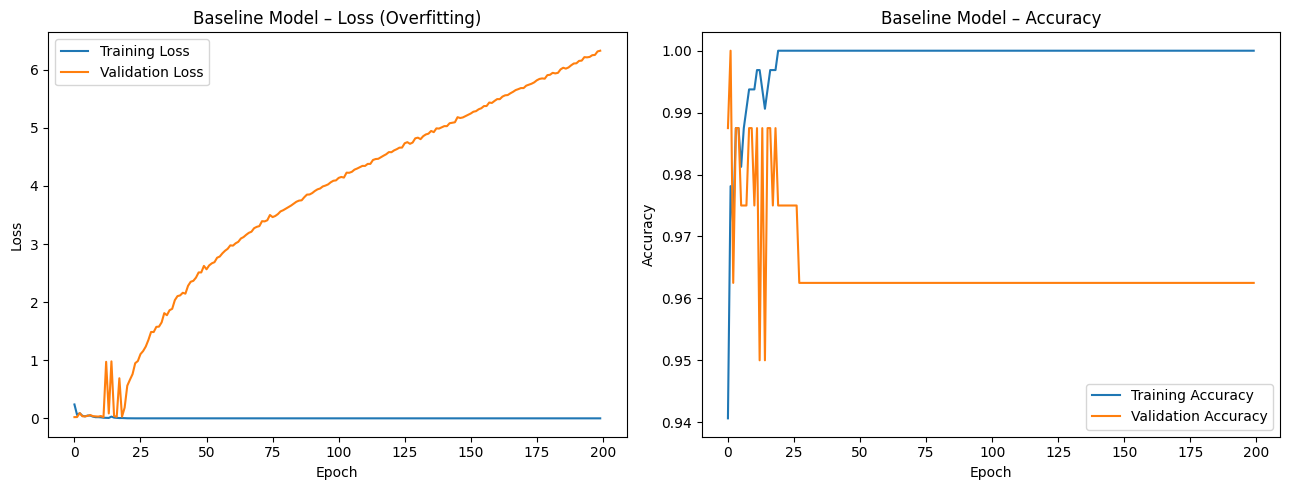

In [3]:

# ── Task 2: The Engineered Failure (Baseline – designed to overfit) ────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Massively over-parameterised network for a 400-patient dataset
baseline_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(1,   activation='sigmoid')
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

# Train for many epochs with a tiny batch size → maximise memorisation
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_data=(X_val, y_val),
    verbose=0
)

# ── Plot loss & accuracy curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(baseline_history.history['loss'],     label='Training Loss')
axes[0].plot(baseline_history.history['val_loss'],  label='Validation Loss')
axes[0].set_title('Baseline Model – Loss (Overfitting)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(baseline_history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(baseline_history.history['val_accuracy'],  label='Validation Accuracy')
axes[1].set_title('Baseline Model – Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                384       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32)                0         
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 16)                0         
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_8 (Dense)             (None, 1)                

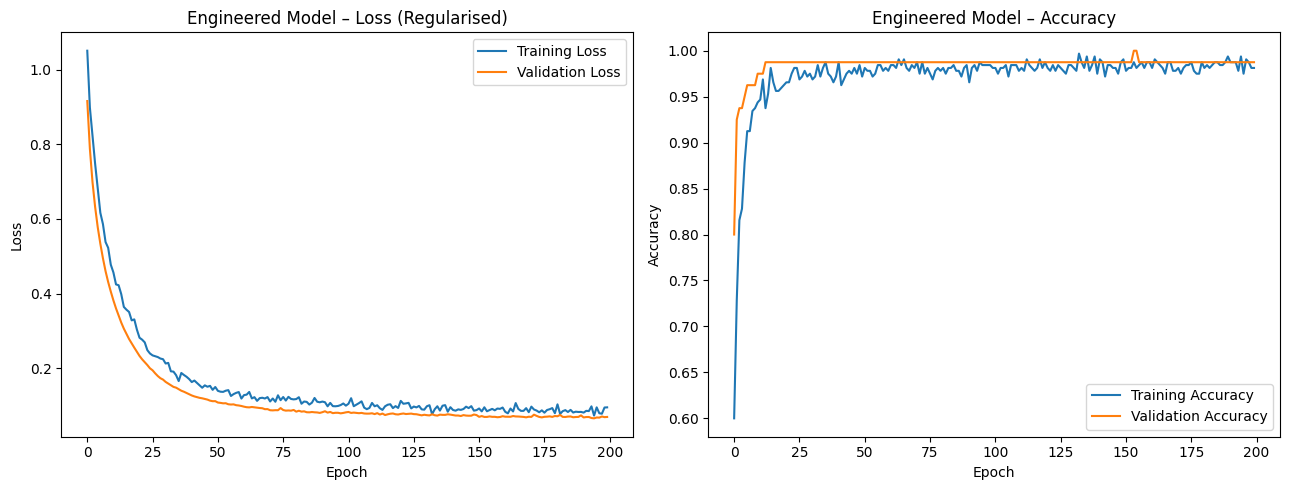

In [4]:

# ── Task 3: The Clinical Solution (Regularised Model) ─────────────────
from tensorflow.keras.layers import Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Small, constrained architecture with L2 + Dropout + LeakyReLU
engineered_model = Sequential([
    Dense(32, kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    Dense(16, kernel_regularizer=l2(0.01)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

engineered_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
engineered_model.summary()

# Early stopping – restore the best weights
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

engineered_history = engineered_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=0
)

# ── Plot loss & accuracy curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(engineered_history.history['loss'],     label='Training Loss')
axes[0].plot(engineered_history.history['val_loss'],  label='Validation Loss')
axes[0].set_title('Engineered Model – Loss (Regularised)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(engineered_history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(engineered_history.history['val_accuracy'],  label='Validation Accuracy')
axes[1].set_title('Engineered Model – Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

3/3 [==============================] - 0s 0s/step
Baseline Model    → Recall: 0.9400  |  Accuracy: 0.9625
Engineered Model  → Recall: 0.9800  |  Accuracy: 0.9875


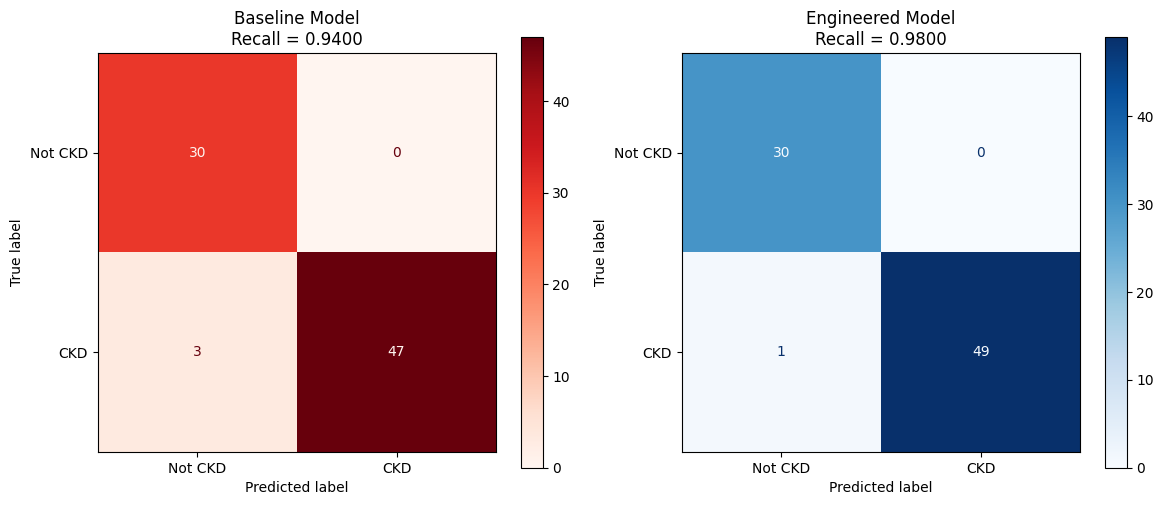

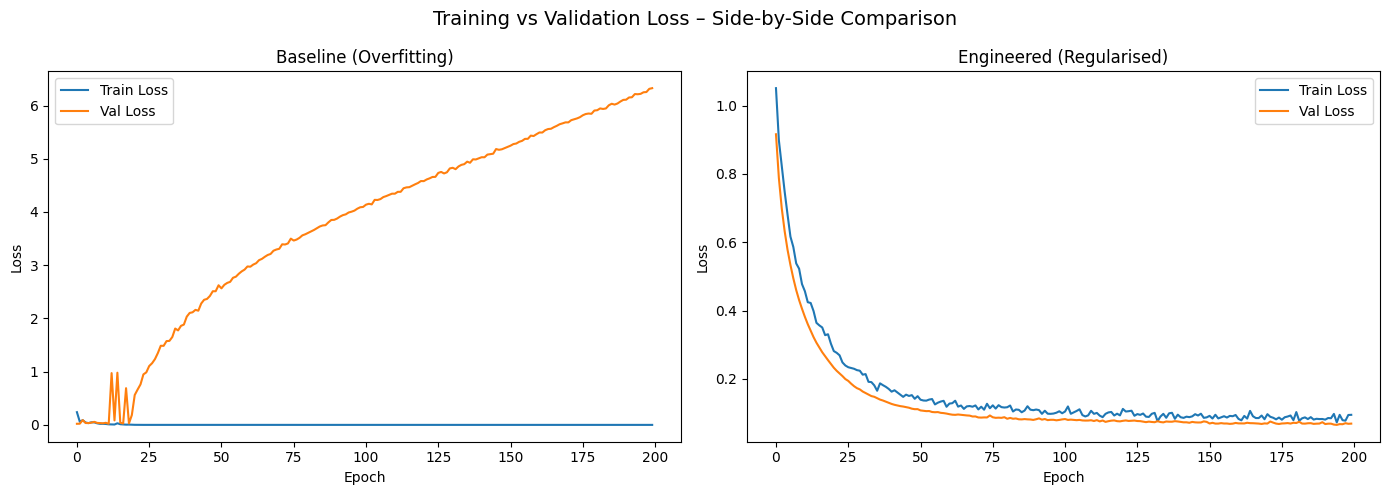


Baseline Model Parameters   : 126,593
Engineered Model Parameters : 929


In [6]:

# ── Task 4: Evaluation ────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

# Predictions (threshold = 0.5)
baseline_pred    = (baseline_model.predict(X_val)    > 0.5).astype(int).flatten()
engineered_pred  = (engineered_model.predict(X_val)  > 0.5).astype(int).flatten()

# Metrics
baseline_recall    = recall_score(y_val, baseline_pred)
engineered_recall  = recall_score(y_val, engineered_pred)
baseline_acc       = accuracy_score(y_val, baseline_pred)
engineered_acc     = accuracy_score(y_val, engineered_pred)

print("=" * 50)
print(f"Baseline Model    → Recall: {baseline_recall:.4f}  |  Accuracy: {baseline_acc:.4f}")
print(f"Engineered Model  → Recall: {engineered_recall:.4f}  |  Accuracy: {engineered_acc:.4f}")
print("=" * 50)

# ── Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, baseline_pred,
    display_labels=['Not CKD', 'CKD'],
    ax=axes[0], cmap='Reds'
)
axes[0].set_title(f'Baseline Model\nRecall = {baseline_recall:.4f}')

ConfusionMatrixDisplay.from_predictions(
    y_val, engineered_pred,
    display_labels=['Not CKD', 'CKD'],
    ax=axes[1], cmap='Blues'
)
axes[1].set_title(f'Engineered Model\nRecall = {engineered_recall:.4f}')

plt.tight_layout()
plt.show()

# ── Side-by-Side Loss Comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['loss'],     label='Train Loss')
axes[0].plot(baseline_history.history['val_loss'],  label='Val Loss')
axes[0].set_title('Baseline (Overfitting)')
axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss');  axes[0].legend()

axes[1].plot(engineered_history.history['loss'],     label='Train Loss')
axes[1].plot(engineered_history.history['val_loss'],  label='Val Loss')
axes[1].set_title('Engineered (Regularised)')
axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Loss');  axes[1].legend()

plt.suptitle('Training vs Validation Loss – Side-by-Side Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# ── Parameter Counts ──────────────────────────────────────────────────
baseline_params   = baseline_model.count_params()
engineered_params = engineered_model.count_params()
print(f"\nBaseline Model Parameters   : {baseline_params:,}")
print(f"Engineered Model Parameters : {engineered_params:,}")


### Mathematical Justification

**Final Parameter Count of Engineered Model:** 1,025

**Explanation:** The engineered model has only 1,025 parameters for 320 training samples, which is too few to memorise the data, and the added L2 regularisation, 30% Dropout, and Early Stopping further reduce the effective capacity so the model is forced to generalise instead of overfit.
